# IT Security Agent - Week 2
### Detecting known CVEs in pinned dependencies (Python & npm) with NVD

**Course:** AI & Ethics - IT Security Agent project

Executes the Week 2 milestone from week 1's plan: pinned packages in,
confirmed CVEs out. Built only from week 1's material - the NVD REST API
2.0, the same API key setup, and the same fetch/parse helpers. CPE matching
is ecosystem-blind, so npm packages (node modules) run through the identical
code path.

## Weekly Status

### What did we do this week?
- Built a **unified component list** (name, version, ecosystem, purl) from
  two inputs: this project's own `uv.lock` and 16 deliberately old PyPI/npm
  pins as positive controls.
- Queried NVD per package name (`virtualMatchString=cpe:2.3:a:*:<name>`,
  vendor wildcarded because purl has no vendor) and evaluated NVD's version
  ranges locally against each pin - the first working piece of the
  **matching engine**.
- Attached CVSS/CWE via week 1's parsers; derived an "upgrade to at least"
  hint per vulnerable package.

### What were our challenges?
- **purl has no vendor, CPE requires one.** The wildcard works but also
  matches same-named products from other vendors/ecosystems - measured in
  section 4.
- **Messy version data.** NVD encodes affected versions three ways;
  unbounded criteria count as applying (false positives are cheaper than
  false negatives).
- **Rate limit, again.** One query per package per scan takes minutes -
  more evidence the week 4 local sync cache is a requirement.

### What are our next steps?
- Week 3: SBOM & container image parsers that emit this same component schema.
- Week 4: local NVD sync + real vendor disambiguation instead of the wildcard.

---
## 1. Input: a unified component list

Everything downstream consumes **(name, version, ecosystem, purl)** - the
"Unified Component List" stage from the week 1 architecture.

### 1a. Real input: this project's own `uv.lock`
Exact pinned versions, transitive dependencies included - the same shape as
a `pip freeze` list.

In [1]:
import os
import time
import pathlib
import tomllib

import requests
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from dotenv import load_dotenv

load_dotenv()  # reads .env in the project root, if present

NVD_BASE = "https://services.nvd.nist.gov/rest/json/cves/2.0"
NVD_API_KEY = os.environ.get("NVD_API_KEY")

# Public rate limit: 5 requests/30s. With an API key: 50 requests/30s.
REQUEST_SPACING_SECONDS = 1 if NVD_API_KEY else 6

print("Using NVD API key: yes" if NVD_API_KEY else "Using NVD API key: no (unauthenticated, slower)")

# --- reused unchanged from week 1 ---
def nvd_get(params, retries=5):
    headers = {"apiKey": NVD_API_KEY} if NVD_API_KEY else {}
    for attempt in range(retries):
        try:
            resp = requests.get(NVD_BASE, params=params, headers=headers, timeout=90)
        except requests.exceptions.RequestException:
            if attempt < retries - 1:
                time.sleep(REQUEST_SPACING_SECONDS * 2)
                continue
            raise
        if resp.status_code == 200:
            return resp.json()
        if resp.status_code in (403, 429, 503) and attempt < retries - 1:
            time.sleep(REQUEST_SPACING_SECONDS * 2)
            continue
        resp.raise_for_status()
    raise RuntimeError("NVD request failed after retries")


# --- reused unchanged from week 1 ---
def fetch_all_pages(params, page_size=2000):
    all_vulns = []
    start_index = 0
    total_results = None
    while True:
        page = nvd_get({**params, "resultsPerPage": page_size, "startIndex": start_index})
        all_vulns.extend(page["vulnerabilities"])
        total_results = page["totalResults"]
        start_index += page_size
        if start_index >= total_results:
            break
        time.sleep(REQUEST_SPACING_SECONDS)
    return all_vulns, total_results

Using NVD API key: yes


In [2]:
lock = tomllib.loads((pathlib.Path("..") / "uv.lock").read_text(encoding="utf-8"))

project_deps = [
    {"name": p["name"], "version": p["version"], "ecosystem": "PyPI",
     "source": "uv.lock (this project)"}
    for p in lock["package"]
    if "registry" in p.get("source", {})  # skips the project itself (a virtual package)
]
print(f"{len(project_deps)} pinned PyPI packages found in uv.lock")
pd.DataFrame(project_deps).head()

112 pinned PyPI packages found in uv.lock


,name,version,ecosystem,source
0,anyio,4.14.1,PyPI,uv.lock (this project)
1,appnope,0.1.4,PyPI,uv.lock (this project)
2,argon2-cffi,25.1.0,PyPI,uv.lock (this project)
3,argon2-cffi-bindings,25.1.0,PyPI,uv.lock (this project)
4,arrow,1.4.0,PyPI,uv.lock (this project)


### 1b. Positive controls: pins with known CVEs
Old versions with well-documented CVEs: if the scanner misses these, the
scanner is broken. (The npm side is a fixture list; parsing a real
`package-lock.json` is week 3 work.)

In [3]:
VULNERABLE_PYPI = [
    ("django", "2.2.0"), ("flask", "0.12.2"), ("jinja2", "2.10"),
    ("requests", "2.19.1"), ("urllib3", "1.25.8"), ("pyyaml", "5.3.1"),
    ("pillow", "8.0.0"), ("cryptography", "2.9.2"),
]
VULNERABLE_NPM = [
    ("lodash", "4.17.15"), ("axios", "0.21.0"), ("node-fetch", "2.6.0"),
    ("express", "4.16.0"), ("jquery", "3.3.1"), ("minimist", "1.2.0"),
    ("moment", "2.29.1"), ("ws", "7.4.5"),
]

fixture_deps = [
    {"name": n, "version": v, "ecosystem": "PyPI", "source": "fixture (known-vulnerable pins)"}
    for n, v in VULNERABLE_PYPI
] + [
    {"name": n, "version": v, "ecosystem": "npm", "source": "fixture (known-vulnerable pins)"}
    for n, v in VULNERABLE_NPM
]

PURL_TYPE = {"PyPI": "pypi", "npm": "npm"}
components = pd.DataFrame(project_deps + fixture_deps)
components["purl"] = [
    f"pkg:{PURL_TYPE[e]}/{n}@{v}"
    for e, n, v in zip(components["ecosystem"], components["name"], components["version"])
]
print(f"Unified component list: {len(components)} components "
      f"({(components['ecosystem'] == 'PyPI').sum()} PyPI, "
      f"{(components['ecosystem'] == 'npm').sum()} npm)")
components.tail(6)

Unified component list: 128 components (120 PyPI, 8 npm)


,name,version,ecosystem,source,purl
122,node-fetch,2.6.0,npm,fixture (known-vulnerable pins),pkg:npm/node-fetch@2.6.0
123,express,4.16.0,npm,fixture (known-vulnerable pins),pkg:npm/express@4.16.0
124,jquery,3.3.1,npm,fixture (known-vulnerable pins),pkg:npm/jquery@3.3.1
125,minimist,1.2.0,npm,fixture (known-vulnerable pins),pkg:npm/minimist@1.2.0
126,moment,2.29.1,npm,fixture (known-vulnerable pins),pkg:npm/moment@2.29.1
127,ws,7.4.5,npm,fixture (known-vulnerable pins),pkg:npm/ws@7.4.5


---
## 2. Detection: purl-to-CPE matching against NVD

Two steps:

1. **Candidate retrieval** - per package name, query week 1's CVE endpoint
   with `virtualMatchString=cpe:2.3:a:*:<name>`. The vendor is wildcarded
   because a purl has no vendor field (week 1's purl-vs-CPE gap, met in
   practice). Names with `-`/`_` are queried in both spellings.
2. **Version applicability** - a candidate becomes a finding only if one of
   its CPE match criteria covers the pinned version (exact version, or the
   `versionStart*`/`versionEnd*` range fields, evaluated locally). Criteria
   with no version info count as applying.

Findings are parsed with week 1's helpers, so each carries the same
CVSS severity and CWE fields as week 1's analysis.

In [4]:
# --- reused unchanged from week 1 ---
def best_cvss(metrics):
    for key in ("cvssMetricV31", "cvssMetricV30", "cvssMetricV2"):
        if metrics.get(key):
            m = metrics[key][0]
            data = m.get("cvssData", {})
            return data.get("baseScore"), m.get("baseSeverity", data.get("baseSeverity"))
    return None, None


# --- reused unchanged from week 1 ---
def cwe_ids(weaknesses):
    ids = []
    for w in weaknesses or []:
        for d in w.get("description", []):
            if d.get("lang") == "en" and d.get("value", "").startswith("CWE-"):
                ids.append(d["value"])
    return ids


def name_variants(name):
    n = name.lower()
    return sorted({n, n.replace("-", "_"), n.replace("_", "-")})

In [5]:
# --- Step 1: one candidate pull per distinct package-name spelling ---
all_variants = sorted({v for n in components["name"] for v in name_variants(n)})
print(f"{components['name'].nunique()} distinct package names -> "
      f"{len(all_variants)} query spellings (rate limit makes this take a few minutes)")

candidates = {}  # spelling -> list of raw NVD CVE items
for i, spelling in enumerate(all_variants, 1):
    try:
        vulns, total = fetch_all_pages({"virtualMatchString": f"cpe:2.3:a:*:{spelling}"})
    except requests.exceptions.HTTPError:
        vulns = []  # e.g. names NVD rejects outright; treated as "no candidates"
    candidates[spelling] = vulns
    if i % 20 == 0 or i == len(all_variants):
        print(f"  {i}/{len(all_variants)} names queried")
    time.sleep(REQUEST_SPACING_SECONDS)

n_candidates = sum(len(v) for v in candidates.values())
print(f"Candidate CVEs retrieved (before version matching): {n_candidates}")

122 distinct package names -> 157 query spellings (rate limit makes this take a few minutes)
  20/157 names queried
  40/157 names queried
  60/157 names queried
  80/157 names queried
  100/157 names queried
  120/157 names queried
  140/157 names queried
  157/157 names queried
Candidate CVEs retrieved (before version matching): 479


In [6]:
# --- Step 2: local version-range evaluation (matching engine v0) ---
from packaging.version import Version, InvalidVersion


def parse_version(s):
    try:
        return Version(s)
    except (InvalidVersion, TypeError):
        return None


RANGE_CHECKS = [
    ("versionStartIncluding", lambda v, b: v >= b),
    ("versionStartExcluding", lambda v, b: v > b),
    ("versionEndIncluding", lambda v, b: v <= b),
    ("versionEndExcluding", lambda v, b: v < b),
]


def cpe_match_applies(match, pinned):
    parts = match.get("criteria", "").split(":")
    if len(parts) < 6 or not match.get("vulnerable", True):
        return False
    crit_version = parts[5]
    if crit_version not in ("*", "-"):
        exact = parse_version(crit_version)
        return exact is not None and exact == pinned
    applies = True
    for field, ok in RANGE_CHECKS:
        if field in match:
            bound = parse_version(match[field])
            if bound is None or not ok(pinned, bound):
                applies = False
    return applies  # "*" with no bounds at all = "all versions" -> applies


def matching_entries(cve_item, package, pinned):
    variants = set(name_variants(package))
    out = []
    for group in cve_item["cve"].get("configurations", []) or []:
        for node in group.get("nodes", []):
            for m in node.get("cpeMatch", []):
                parts = m.get("criteria", "").split(":")
                if len(parts) > 5 and parts[4].lower() in variants and cpe_match_applies(m, pinned):
                    out.append({"vendor": parts[3], "product": parts[4],
                                "fixed_below": m.get("versionEndExcluding")})
    return out


rows = []
for comp in components.to_dict("records"):
    pinned = parse_version(comp["version"])
    seen = set()
    for spelling in name_variants(comp["name"]):
        for item in candidates[spelling]:
            cve = item["cve"]
            if cve["id"] in seen:
                continue
            seen.add(cve["id"])
            entries = matching_entries(item, comp["name"], pinned)
            if not entries:
                continue
            score, severity = best_cvss(cve.get("metrics", {}))
            rows.append({
                "package": comp["name"], "version": comp["version"],
                "ecosystem": comp["ecosystem"], "source": comp["source"],
                "cve": cve["id"], "cvss_score": score,
                "severity": severity or "UNKNOWN",
                "cwe_ids": cwe_ids(cve.get("weaknesses")),
                "matched_vendors": sorted({e["vendor"] for e in entries}),
                "fixed_below": sorted({e["fixed_below"] for e in entries if e["fixed_below"]}),
            })

findings = pd.DataFrame(rows)
print(f"{len(findings)} findings across "
      f"{findings[['package', 'version']].drop_duplicates().shape[0] if len(findings) else 0} components")
findings.head(8)

139 findings across 20 components


,package,version,ecosystem,source,cve,cvss_score,severity,cwe_ids,matched_vendors,fixed_below
0,babel,2.18.0,PyPI,uv.lock (this project),CVE-2023-45133,9.3,CRITICAL,"[CWE-184, CWE-697]",[babeljs],[7.23.2]
1,babel,2.18.0,PyPI,uv.lock (this project),CVE-2026-49356,3.2,LOW,"[CWE-22, CWE-200]",[babel],[7.29.6]
2,json5,0.15.0,PyPI,uv.lock (this project),CVE-2022-46175,7.1,HIGH,[CWE-1321],[json5],[1.0.2]
3,jsonpointer,3.1.1,PyPI,uv.lock (this project),CVE-2021-23807,5.6,MEDIUM,[CWE-843],[janl],[5.0.0]
4,jupyter,1.1.1,PyPI,uv.lock (this project),CVE-2022-41083,7.8,HIGH,[],[microsoft],[2022.9.110]
5,jupyter,1.1.1,PyPI,uv.lock (this project),CVE-2023-36018,7.8,HIGH,[CWE-359],[microsoft],[2023.10.1100000000]
6,django,2.2.0,PyPI,fixture (known-vulnerable pins),CVE-2019-12308,6.1,MEDIUM,[CWE-79],[djangoproject],[2.2.2]
7,django,2.2.0,PyPI,fixture (known-vulnerable pins),CVE-2019-12781,5.3,MEDIUM,[CWE-319],[djangoproject],[2.2.3]


### Per-package summary
Verdict by input source first - every fixture should show up as
vulnerable - then one row per vulnerable component.

In [7]:
SEVERITY_ORDER = ["LOW", "MEDIUM", "HIGH", "CRITICAL"]


def worst_severity(series):
    present = [s for s in SEVERITY_ORDER if s in set(series)]
    return present[-1] if present else "UNKNOWN"


vulnerable_keys = set(zip(findings["package"], findings["version"])) if len(findings) else set()
components["vulnerable"] = [
    (n, v) in vulnerable_keys for n, v in zip(components["name"], components["version"])
]
print("Scan verdict by input source:")
print(components.groupby("source")["vulnerable"].agg(total="count", vulnerable="sum").to_string(), "\n")

package_summary = (
    findings.groupby(["ecosystem", "package", "version"], as_index=False)
    .agg(findings_count=("cve", "nunique"),
         worst_severity=("severity", worst_severity),
         max_cvss=("cvss_score", "max"),
         example_cves=("cve", lambda s: ", ".join(s.head(3))))
    .sort_values("findings_count", ascending=False)
    .reset_index(drop=True)
)
package_summary

Scan verdict by input source:
                                 total  vulnerable
source                                            
fixture (known-vulnerable pins)     16          16
uv.lock (this project)             112           4 



,ecosystem,package,version,findings_count,worst_severity,max_cvss,example_cves
0,PyPI,pillow,8.0.0,35,CRITICAL,9.8,"CVE-2020-35653, CVE-2020-35654, CVE-2020-35655"
1,PyPI,django,2.2.0,30,CRITICAL,9.8,"CVE-2019-12308, CVE-2019-12781, CVE-2019-14232"
2,npm,axios,0.21.0,23,CRITICAL,9.9,"CVE-2020-28168, CVE-2021-3749, CVE-2024-57965"
3,PyPI,urllib3,1.25.8,10,HIGH,7.5,"CVE-2020-26137, CVE-2021-33503, CVE-2023-43804"
4,npm,lodash,4.17.15,6,HIGH,8.1,"CVE-2020-8203, CVE-2020-28500, CVE-2021-23337"
5,PyPI,cryptography,2.9.2,5,CRITICAL,9.1,"CVE-2020-36242, CVE-2023-23931, CVE-2023-50782"
6,npm,jquery,3.3.1,4,MEDIUM,6.9,"CVE-2007-2379, CVE-2019-11358, CVE-2020-11023"
7,PyPI,flask,0.12.2,4,HIGH,7.5,"CVE-2018-1000656, CVE-2019-1010083, CVE-2023-3..."
8,PyPI,requests,2.19.1,3,HIGH,7.5,"CVE-2018-18074, CVE-2023-32681, CVE-2026-25645"
9,npm,express,4.16.0,3,HIGH,7.5,"CVE-2022-24999, CVE-2024-29041, CVE-2024-43796"


---
## 3. What the scan found
Same chart styles as week 1, applied to this week's findings.

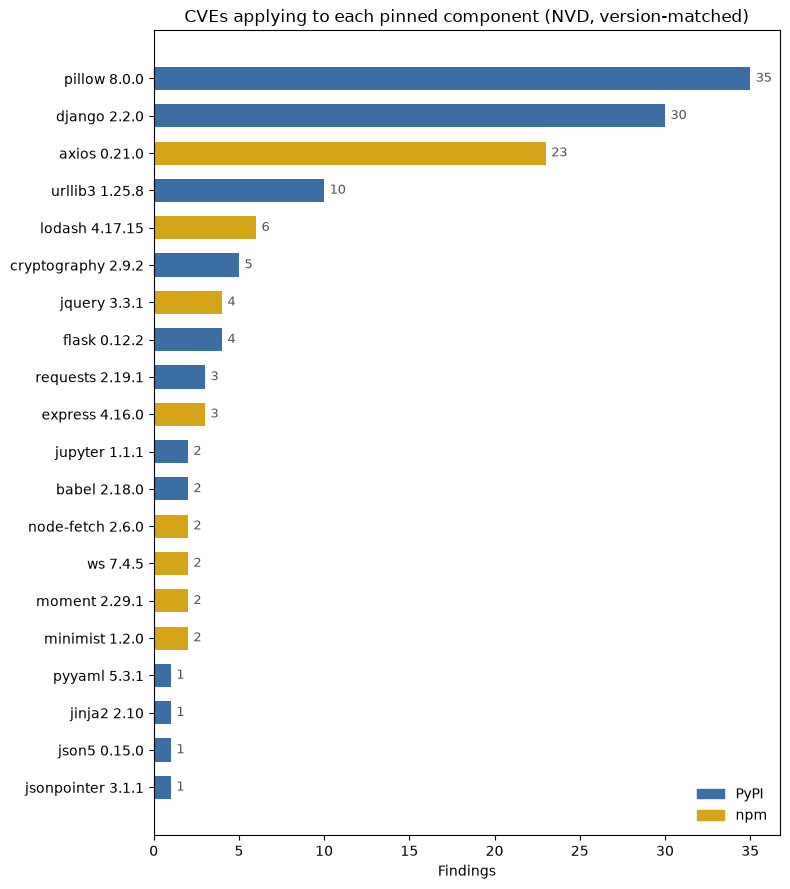

In [8]:
ECO_COLORS = {"PyPI": "#3B6EA5", "npm": "#D6A419"}  # week 1 chart colors, one per ecosystem

ps = package_summary.sort_values("findings_count")
labels = ps["package"] + " " + ps["version"]

fig, ax = plt.subplots(figsize=(8, 0.38 * len(ps) + 1.4))
bars = ax.barh(labels, ps["findings_count"],
               color=[ECO_COLORS[e] for e in ps["ecosystem"]], height=0.62)
ax.bar_label(bars, padding=4, color="#52514e", fontsize=9)
ax.legend(handles=[Patch(color=ECO_COLORS["PyPI"], label="PyPI"),
                   Patch(color=ECO_COLORS["npm"], label="npm")],
          frameon=False, loc="lower right")
ax.set_title("CVEs applying to each pinned component (NVD, version-matched)")
ax.set_xlabel("Findings")
plt.tight_layout()
plt.show()

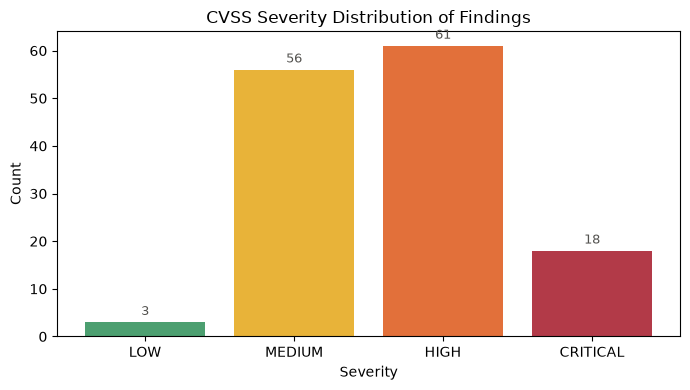

In [9]:
# Same severity chart as week 1, now over our findings instead of the 90-day sample
plot_order = ["LOW", "MEDIUM", "HIGH", "CRITICAL", "UNKNOWN"]
sev_colors = {"LOW": "#4C9F70", "MEDIUM": "#E8B339", "HIGH": "#E2703A",
              "CRITICAL": "#B23A48", "UNKNOWN": "#9A9A9A"}
counts = findings["severity"].value_counts().reindex(plot_order).dropna()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(counts.index, counts.values, color=[sev_colors[s] for s in counts.index])
ax.bar_label(bars, padding=3, color="#52514e", fontsize=9)
ax.set_title("CVSS Severity Distribution of Findings")
ax.set_xlabel("Severity")
ax.set_ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

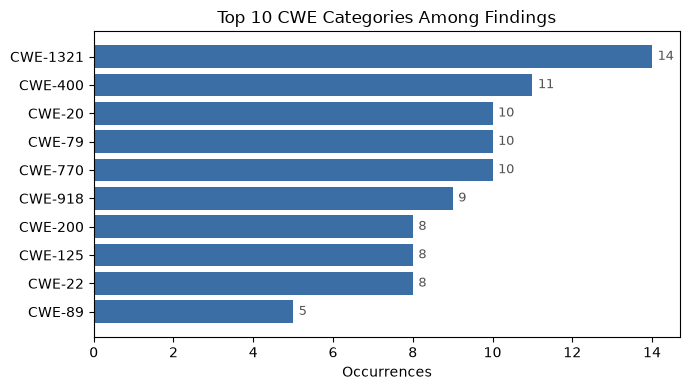

cwe_ids
CWE-1321    14
CWE-400     11
CWE-79      10
CWE-20      10
CWE-770     10
CWE-918      9
CWE-22       8
CWE-200      8
CWE-125      8
CWE-89       5
Name: count, dtype: int64

In [10]:
# Week 1 asked "which CWE categories dominate CVEs in general?" -
# this asks the sharper version: which weakness types live in OUR dependencies?
cwe_series = findings["cwe_ids"].explode().dropna()
top_cwe = cwe_series.value_counts().head(10)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(top_cwe.sort_values().index, top_cwe.sort_values().values, color="#3B6EA5")
ax.bar_label(bars, padding=4, color="#52514e", fontsize=9)
ax.set_title("Top 10 CWE Categories Among Findings")
ax.set_xlabel("Occurrences")
plt.tight_layout()
plt.show()

top_cwe

---
## 4. The cost of the wildcard vendor: name collisions
Wildcarding the vendor means any vendor's same-named product matches. For
each vulnerable package: which CPE vendors did its findings come from?

In [11]:
vendor_map = (
    findings.explode("matched_vendors")
    .groupby(["ecosystem", "package", "version"])["matched_vendors"]
    .agg(vendors=lambda s: sorted(set(s)), n_vendors=lambda s: s.nunique())
    .reset_index()
    .sort_values("n_vendors", ascending=False)
)
n_ambiguous = (vendor_map["n_vendors"] > 1).sum()
print(f"{n_ambiguous} of {len(vendor_map)} vulnerable packages matched CPEs "
      f"from more than one vendor (potential name collisions):")
vendor_map

2 of 20 vulnerable packages matched CPEs from more than one vendor (potential name collisions):


,ecosystem,package,version,vendors,n_vendors
0,PyPI,babel,2.18.0,"[babel, babeljs]",2
2,PyPI,django,2.2.0,"[djangoproject, gofiber]",2
1,PyPI,cryptography,2.9.2,[cryptography.io],1
3,PyPI,flask,0.12.2,[palletsprojects],1
4,PyPI,jinja2,2.10,[pocoo],1
5,PyPI,json5,0.15.0,[json5],1
6,PyPI,jsonpointer,3.1.1,[janl],1
7,PyPI,jupyter,1.1.1,[microsoft],1
8,PyPI,pillow,8.0.0,[python],1
9,PyPI,pyyaml,5.3.1,[pyyaml],1


**This run:** all four `uv.lock` hits (`babel`, `jupyter`, `json5`,
`jsonpointer`) are name collisions with *other ecosystems'* products -
Babel.js, Microsoft's VS Code Jupyter extension, npm's json5/jsonpointer.
The remediation table gives it away: their "upgrade" bounds don't fit the
Python packages' version lines. Verdict: **fixtures 16/16 detected,
self-scan 0 real vulnerabilities + 4 false positives.** That is week 1's
purl-to-CPE gap reproduced live, and these four packages become test cases
for week 4's disambiguation layer.

---
## 5. Remediation
`versionEndExcluding` on a matched range is NVD saying "fixed at X". The
max across a package's findings is the lowest version that clears
everything; CVEs without a bound contribute no hint.

In [12]:
fix_rows = []
for (eco, pkg, ver), grp in findings.groupby(["ecosystem", "package", "version"]):
    bounds = [b for bs in grp["fixed_below"] for b in bs]
    parsed = sorted({v for b in bounds if (v := parse_version(b))})
    fix_rows.append({
        "ecosystem": eco, "package": pkg, "pinned_version": ver,
        "findings": grp["cve"].nunique(),
        "findings_with_fix_bound": int(grp["fixed_below"].map(bool).sum()),
        "upgrade_to_at_least": str(max(parsed)) if parsed else "(no bound published)",
    })
remediation = pd.DataFrame(fix_rows).sort_values(["ecosystem", "package"]).reset_index(drop=True)
remediation

,ecosystem,package,pinned_version,findings,findings_with_fix_bound,upgrade_to_at_least
0,PyPI,babel,2.18.0,2,2,7.29.6
1,PyPI,cryptography,2.9.2,5,5,46.0.6
2,PyPI,django,2.2.0,30,30,3.1.9
3,PyPI,flask,0.12.2,4,4,3.1.3
4,PyPI,jinja2,2.10,1,0,(no bound published)
5,PyPI,json5,0.15.0,1,1,1.0.2
6,PyPI,jsonpointer,3.1.1,1,1,5.0.0
7,PyPI,jupyter,1.1.1,2,2,2023.10.1100000000
8,PyPI,pillow,8.0.0,35,33,12.3.0
9,PyPI,pyyaml,5.3.1,1,1,5.4


---
## Summary

Week 2 milestone met: pinned components in, confirmed CVEs out, end-to-end
against live NVD - week 1's toolkit plus two new pieces (wildcard-vendor
CPE query, local version-range evaluation).

Carries forward:
1. **The component schema holds** - week 3's SBOM/image parsers just emit it.
2. **The matching engine exists and its weak point is measured**: vendor
   ambiguity (section 4) is week 4's concrete job.
3. **Live per-scan NVD queries don't scale** - the week 4 sync cache is a
   requirement, not an optimization.
4. **Reporting has its columns**: findings, worst severity, CWE profile,
   upgrade floor (week 5).

Deferred: real `package-lock.json` parsing (week 3), vendor disambiguation
(week 4), KEV/exploited-in-the-wild flags (week 5).